# Feature set extraction and data cleaning

In [55]:
# Standard library
import math
from collections import Counter

# Data
import numpy as np
import pandas as pd

# NLP
import nltk
import spacy
from spacy.language import Language
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import torch

# ML
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity

# Stats / distance
from scipy.spatial.distance import cdist

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

@Language.component("semicolon_sentencizer")
def semicolon_sentencizer(doc):
    for token in doc[:-1]:
        if token.text in [";", "--", "—"]:
            doc[token.i + 1].is_sent_start = True
        elif token.text == "-" and token.i > 0 and doc[token.i - 1].text == "-":
            doc[token.i + 1].is_sent_start = True
    return doc

nltk.download("stopwords")
functionWords = set(stopwords.words("english"))

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("semicolon_sentencizer", before="parser")

sentenceModel = SentenceTransformer("all-MiniLM-L6-v2")

gpt2Model = GPT2LMHeadModel.from_pretrained("gpt2")
gpt2Tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2Model.eval()

authorSpecificDf = pd.read_csv("/content/drive/MyDrive/FYP/authorSpecific.csv", encoding="latin")
generalPassagesDf = pd.read_csv("/content/drive/MyDrive/FYP/generalPassages.csv", encoding="latin")

dataFrames = [authorSpecificDf, generalPassagesDf]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [56]:
POS_TAGS = ["ADJ",
    "ADP",
    "ADV",
    "AUX",
    "CCONJ",
    "DET",
    "INTJ",
    "NOUN",
    "NUM",
    "PART",
    "PRON",
    "PROPN",
    "SCONJ",
    "VERB",]

DEP_CLAUSES = ["mark",
               "advcl",
               "ccomp",
               "xcomp",
               "acl",
               "relcl",]

posTagRename = {
    "NOUN": "nounUsagePerToken",
    "VERB": "verbUsagePerToken",
    "ADJ": "adjectiveUsagePerToken",
    "ADV": "adverbUsagePerToken",
    "PRON": "pronounUsagePerToken",
    "PROPN": "properNounUsagePerToken",
    "DET": "determinerUsagePerToken",
    "ADP": "adpositionUsagePerToken",
    "AUX": "auxiliaryVerbUsagePerToken",
    "CCONJ": "coordConjUsagePerToken",
    "SCONJ": "subordConjUsagePerToken",
    "PART": "particleUsagePerToken",
    "NUM": "numeralUsagePerToken",
    "INTJ": "interjectionUsagePerToken"
}

depClauseRename = {
    "mark": "markerDependencyClauseDensity",
    "advcl": "adverbialDependencyClauseDensity",
    "ccomp": "complementDependencyClauseDensity",
    "xcomp": "openComplementDependencyClauseDensity",
    "acl": "adjectivalDependencyClauseDensity",
    "relcl": "relativeDependencyClauseDensity"
}



In [57]:
def functionWordRate(doc):
  words = [token.text.lower() for token in doc if token.is_alpha]
  nTokens = len(words) or 1
  counter = 0
  for word in words:
    if word in functionWords:
      counter += 1
  return counter/nTokens

def sentenceLength(doc):
  lengths = []

  for sent in doc.sents:
    sentLength = 0

    for token in sent:
      if token.is_alpha:
        sentLength += 1

    lengths.append(sentLength)

  return lengths

def meanSentenceLength(doc):
  lengths = sentenceLength(doc)

  if not lengths or len(lengths) <= 1:
    return 0.0

  return float(np.mean(lengths))

def stdDeviationSentenceLength(doc):
  lengths = sentenceLength(doc)

  if not lengths or len(lengths) <= 1:
    return 0.0

  return float(np.std(lengths))

def sentenceLengthvariation(doc):
  std = stdDeviationSentenceLength(doc)
  if std == 0:
    return 0.0
  return meanSentenceLength(doc) / std

def lexicalBurstiness(doc):
  words = [token.lower_ for token in doc if token.is_alpha]

  if len(words) < 2:
    return 0.0

  counts = Counter(words)
  frequencies = list(counts.values())

  if len(frequencies) < 2:
    return 0.0

  meanFreq = np.mean(frequencies)
  stdFreq = np.std(frequencies)

  if meanFreq == 0:
    return 0.0
  else:
    return stdFreq / meanFreq

def sentenceParseDepth(sent):
  def depth(token):
    if not list(token.children):
      return 0
    return 1 + max(depth(child) for child in token.children if child in sent)

  return depth(sent.root)

def parseTreeDepth(doc):
  sents = list(doc.sents)
  if len(sents) <= 1:
    return [0]
  return [sentenceParseDepth(sent) for sent in sents]

def meanTreeDepth(doc):
  treeDepths = parseTreeDepth(doc)

  if not treeDepths:
    return 0.0

  return float(np.mean(treeDepths))

def stdDeviationTreeDepth(doc):
  treeDepths = parseTreeDepth(doc)

  if not treeDepths:
    return 0.0

  return float(np.std(treeDepths))

def posTagRate(doc, posTag):
  tagCount = 0
  total = 0

  for token in doc:
    if token.is_alpha:
      total += 1
      if token.pos_ == posTag:
        tagCount += 1

  if total == 0:
    return 0.0

  return tagCount / total

def posNgramRepetition(doc, n):
  posTags = [t.pos_ for t in doc if t.is_alpha]

  grams = []

  for i in range(len(posTags) - n + 1):

    gram = []

    for j in range(n):
      if(i+j < len(posTags)):
        gram.append(posTags[i+j])

    grams.append(tuple(gram))

  total = len(grams)
  unique = len(set(grams))

  if total == 0:
    return 0.0

  return 1.0 - (unique / total)

def ngramRepetition(doc, n, useLemma = True):

  if useLemma:
    tokens = [t.lemma_.lower() for t in doc if t.is_alpha]
  else:
    tokens = [t.text.lower() for t in doc if t.is_alpha]

  if len(tokens) < n * 3:
    return 0.0

  ngrams = list(zip(*[tokens[i:] for i in range(n)]))
  total = len(ngrams)
  unique = len(set(ngrams))

  if total == 0:
    return 0.0

  return 1.0 - (unique / total)

def calculateSentenceLengthVariation(doc):

    sentences = list(doc.sents)

    if len(sentences) <= 1:
      return 0.0

    sentenceLengths = [len(sent) for sent in sentences]

    meanLength = np.mean(sentenceLengths)
    stdLength = np.std(sentenceLengths)

    if meanLength == 0:
        return 0

    coefficientVariation = stdLength / meanLength
    return coefficientVariation

def clauseDensity(doc, dep):

  depCounter = 0
  sentenceCounter = 0

  for sent in doc.sents:
    for token in sent:
      if token.dep_ == dep:
        depCounter += 1
    sentenceCounter += 1

  if sentenceCounter == 0:
    return 0.0

  return depCounter / sentenceCounter

def calculateRTTR(doc, useLemma = True):
  if useLemma:
    tokens = [t.lemma_.lower() for t in doc if t.is_alpha]
  else:
    tokens = [t.text.lower() for t in doc if t.is_alpha]

  totalTokens = len(tokens)
  uniqueTokens = len(set(tokens))

  if totalTokens == 0:
    return 0.0

  return uniqueTokens / math.sqrt(totalTokens)

def semanticCosineSimilarity(doc):
    sentences = [sent.text for sent in doc.sents]

    if len(sentences) <= 1:
        return 0.0

    embeddings = sentenceModel.encode(sentences)

    similarities = []
    for i in range(len(embeddings) - 1):
        sim = cosine_similarity([embeddings[i]], [embeddings[i + 1]])[0][0]
        similarities.append(sim)

    return float(np.mean(similarities))

def calculatePerplexityAndSurprisal(text):
    inputs = gpt2Tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

    with torch.no_grad():
        outputs = gpt2Model(**inputs, labels=inputs["input_ids"])

    loss = outputs.loss.item()
    perplexity = math.exp(loss)
    surprisal = loss

    return perplexity, surprisal




In [58]:
N_TOPICS = 12
for df in dataFrames:

  df["doc"] = df["Text Passage"].apply(nlp)

"""
  df["functionWordRate"] = df["doc"].apply(functionWordRate)
  df["meanSentenceLength"] = df["doc"].apply(meanSentenceLength)
  df["stdDeviationSentenceLength"] = df["doc"].apply(stdDeviationSentenceLength)
  df["sentenceLengthVariation"] = df["doc"].apply(sentenceLengthvariation)
  df["lexicalBurstiness"] = df["doc"].apply(lexicalBurstiness)
  df["meanTreeDepth"] = df["doc"].apply(meanTreeDepth)
  df["stdDeviationTreeDepth"] = df["doc"].apply(stdDeviationTreeDepth)
  df["bigramRepetition"] = df["doc"].apply(lambda x: ngramRepetition(x, n=2, useLemma = True))
  df["trigramRepetition"] = df["doc"].apply(lambda x: ngramRepetition(x, n=3, useLemma = True))
  df["quadgramRepetition"] = df["doc"].apply(lambda x: ngramRepetition(x, n=4, useLemma = True))
  df["calculateSentenceLengthVariation"] = df["doc"].apply(calculateSentenceLengthVariation)
  df["bigramPOSRepetition"] = df["doc"].apply(lambda doc: posNgramRepetition(doc, n=2))
  df["trigramPOSRepetition"] = df["doc"].apply(lambda doc: posNgramRepetition(doc, n=3))
  df["typeTokenRatio"] = df["doc"].apply(calculateRTTR)
  df["cosineSimilarity"] = df["doc"].apply(semanticCosineSimilarity)

  for posTag in POS_TAGS:
    for posName in posTagRename:
      if(posTag == posName):
        df[posTagRename[posTag]] = df["doc"].apply(lambda doc: posTagRate(doc, posTag))

  for dep in DEP_CLAUSES:
    for depName in depClauseRename:
      if(dep == depName):
        df[depClauseRename[dep]] = df["doc"].apply(lambda doc: clauseDensity(doc, dep))

  perplexityScores = []
  surprisalScores = []

  for text in df["Text Passage"]:
      perplexity, surprisal = calculatePerplexityAndSurprisal(text)
      perplexityScores.append(perplexity)
      surprisalScores.append(surprisal)

  df["perplexity"] = perplexityScores
  df["surprisal"] = surprisalScores
  """

vectorizer = CountVectorizer(max_features=1000, stop_words="english")
dtm = vectorizer.fit_transform(authorSpecificDf["Text Passage"])

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=1)
topicDistributions = lda.fit_transform(dtm)

for topicIndex in range(N_TOPICS):
  topicTitle = ("LDATopic " + str(topicIndex + 1))
  authorSpecificDf[topicTitle] = authorSpecificDf["doc"].apply(lambda x: lda.transform(vectorizer.transform([x.text]))[0][topicIndex])

In [59]:
print(generalPassagesDf.shape)
print(authorSpecificDf.shape)

(400, 3)
(600, 15)


In [60]:
#authorSpecificDf.to_csv("/content/drive/MyDrive/FYP/authorSpecificDfFeatures.csv")
#generalPassagesDf.to_csv("/content/drive/MyDrive/FYP/generalPassagesDfFeatures.csv")

In [61]:
authorSpecificDf = pd.read_csv("/content/drive/MyDrive/FYP/authorSpecificDfFeatures.csv", encoding="latin")
generalPassagesDf = pd.read_csv("/content/drive/MyDrive/FYP/generalPassagesDfFeatures.csv", encoding="latin")
authorSpecificDf["doc"] = authorSpecificDf["Text Passage"].apply(nlp)
generalPassagesDf["doc"] = generalPassagesDf["Text Passage"].apply(nlp)

generalPassagesDf = generalPassagesDf.drop(columns=["Unnamed: 0"])
authorSpecificDf = authorSpecificDf.drop(columns=["Unnamed: 0"])


In [62]:
print(authorSpecificDf.shape)
print(generalPassagesDf.shape)

print(generalPassagesDf.columns)
print(authorSpecificDf.columns)

(600, 52)
(400, 40)
Index(['Author', 'Text Passage', 'doc', 'functionWordRate',
       'meanSentenceLength', 'stdDeviationSentenceLength',
       'sentenceLengthVariation', 'lexicalBurstiness', 'meanTreeDepth',
       'stdDeviationTreeDepth', 'bigramRepetition', 'trigramRepetition',
       'quadgramRepetition', 'calculateSentenceLengthVariation',
       'bigramPOSRepetition', 'trigramPOSRepetition', 'typeTokenRatio',
       'cosineSimilarity', 'adjectiveUsagePerToken', 'adpositionUsagePerToken',
       'adverbUsagePerToken', 'auxiliaryVerbUsagePerToken',
       'coordConjUsagePerToken', 'determinerUsagePerToken',
       'interjectionUsagePerToken', 'nounUsagePerToken',
       'numeralUsagePerToken', 'particleUsagePerToken', 'pronounUsagePerToken',
       'properNounUsagePerToken', 'subordConjUsagePerToken',
       'verbUsagePerToken', 'markerDependencyClauseDensity',
       'adverbialDependencyClauseDensity', 'complementDependencyClauseDensity',
       'openComplementDependencyClauseDe

In [63]:
topicColumns = ["LDATopic " + str(i+1) for i in range(N_TOPICS)]

authorTopicMeans = authorSpecificDf.groupby("Author")[topicColumns].mean()

authorTopicMeans["dominantTopic"] = authorTopicMeans.idxmax(axis=1)

print(authorTopicMeans["dominantTopic"])

featureNames = vectorizer.get_feature_names_out()

for topicIndex in range(N_TOPICS):
  topic = lda.components_[topicIndex]
  topTerms = topic.argsort()[-10:][::-1]
  topWords = featureNames[topTerms]
  print("\n\n Most used words: ", topWords, ": for topic" , topicIndex+1)

Author
Cormac McCarthy                 LDATopic 5
GPT-4o Cormac McCarthy          LDATopic 8
GPT-4o George Orwell            LDATopic 9
GPT-4o Mary Wollstonecraft     LDATopic 11
GPT-4o Salinger                 LDATopic 4
GPT-5 Cormac McCarthy           LDATopic 5
GPT-5 George Orwell             LDATopic 7
GPT-5 Mary Wollstonecraft       LDATopic 1
GPT-5 Salinger                  LDATopic 4
George Orwell                   LDATopic 3
Mary Wollstonecraft Shelley    LDATopic 12
Salinger                        LDATopic 3
Name: dominantTopic, dtype: object


 Most used words:  ['let' 'truth' 'like' 'virtue' 'principle' 'shall' 'duty' 'taught'
 'domestic' 'life'] : for topic 1


 Most used words:  ['children' 'boy' 'lady' 'party' 'kind' 'head' 'man' 'life' 'face' 'hair'] : for topic 2


 Most used words:  ['said' 'just' 'don' 'know' 'franny' 'zooey' 'like' 'think' 'glass'
 'little'] : for topic 3


 Most used words:  ['like' 'said' 'way' 'just' 'little' 'kind' 'people' 'thing' 'told' 'iã'] :

In [64]:
featureCols = [
    "functionWordRate",
    "meanSentenceLength",
    "stdDeviationSentenceLength",
    "sentenceLengthVariation",
    "calculateSentenceLengthVariation",
    "lexicalBurstiness",
    "typeTokenRatio",
    "meanTreeDepth",
    "stdDeviationTreeDepth",
    "bigramRepetition",
    "trigramRepetition",
    "quadgramRepetition",
    "bigramPOSRepetition",
    "trigramPOSRepetition",
    "cosineSimilarity",
    "perplexity",
    "surprisal",
    "nounUsagePerToken",
    "verbUsagePerToken",
    "adjectiveUsagePerToken",
    "adverbUsagePerToken",
    "pronounUsagePerToken",
    "properNounUsagePerToken",
    "determinerUsagePerToken",
    "adpositionUsagePerToken",
    "auxiliaryVerbUsagePerToken",
    "coordConjUsagePerToken",
    "subordConjUsagePerToken",
    "particleUsagePerToken",
    "numeralUsagePerToken",
    "interjectionUsagePerToken",
    "markerDependencyClauseDensity",
    "adverbialDependencyClauseDensity",
    "complementDependencyClauseDensity",
    "openComplementDependencyClauseDensity",
    "adjectivalDependencyClauseDensity",
    "relativeDependencyClauseDensity",
    #*["LDATopic " + str(i + 1) for i in range(N_TOPICS)],
]

# Feature Inference

In [65]:
xFeatures = authorSpecificDf[featureCols].to_numpy()

scaler = StandardScaler()
xScaled = scaler.fit_transform(xFeatures)

k = 12
kmeans = KMeans(n_clusters=k, random_state=1, n_init="auto")
labels = kmeans.fit_predict(xScaled)

authorSpecificDf["cluster"] = labels

In [66]:
print(pd.crosstab(authorSpecificDf["Author"], authorSpecificDf["cluster"]))

cluster                      0   1   2   3   4   5   6   7   8   9   10  11
Author                                                                     
Cormac McCarthy               1   8  25   2   1   0  12   0   0   0   0   1
GPT-4o Cormac McCarthy       43   0   0   0   0   0   0   0   0   7   0   0
GPT-4o George Orwell         48   0   0   0   0   0   0   0   0   2   0   0
GPT-4o Mary Wollstonecraft    4   0   0   0   0   0   0   0   0  46   0   0
GPT-4o Salinger              25   3  13   0   0   0   2   0   7   0   0   0
GPT-5 Cormac McCarthy         0   0   0   0  46   2   0   0   0   0   2   0
GPT-5 George Orwell           0   5   0  44   0   0   0   0   1   0   0   0
GPT-5 Mary Wollstonecraft     0   4   0   2   0   0   0   0   0   0   0  44
GPT-5 Salinger                0   3   3   8   0   0   0   4  32   0   0   0
George Orwell                 0  21  25   0   0   0   4   0   0   0   0   0
Mary Wollstonecraft Shelley   0  32  13   2   0   0   0   0   1   0   0   2
Salinger    

In [67]:
centroids = kmeans.cluster_centers_

distance = cdist(centroids, centroids, metric="euclidean")

index = []
columns = []

for i in range(k):
  index.append("Cluster " + str(i))
  columns.append("Cluster " + str(i))

distDf = pd.DataFrame(distance,index, columns)
distDf



,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11
Cluster 0,0.000000,6.686623,4.906581,4.622811,7.201859,26.993724,9.045763,14.872121,6.393314,2.507254,28.025818,5.075491
Cluster 1,6.686623,0.000000,3.339267,4.805728,8.335405,27.521547,5.155471,14.158265,4.346913,6.771556,28.346988,5.304880
Cluster 2,4.906581,3.339267,0.000000,3.891307,7.406314,27.210942,5.500142,14.284120,4.555012,5.616518,28.363738,5.374854
Cluster 3,4.622811,4.805728,3.891307,0.000000,6.223285,26.398306,7.693125,13.746586,4.315158,5.385915,27.495136,2.929392
Cluster 4,7.201859,8.335405,7.406314,6.223285,0.000000,23.724129,10.024845,12.771351,6.921046,6.781910,26.661834,6.651244
Cluster 5,26.993724,27.521547,27.210942,26.398306,23.724129,0.000000,28.537645,17.112074,25.139466,26.544206,28.642359,26.249720
Cluster 6,9.045763,5.155471,5.500142,7.693125,10.024845,28.537645,0.000000,15.217126,6.109696,9.407540,29.078026,8.554777
Cluster 7,14.872121,14.158265,14.284120,13.746586,12.771351,17.112074,15.217126,0.000000,11.107618,14.374958,24.481528,13.466357
Cluster 8,6.393314,4.346913,4.555012,4.315158,6.921046,25.139466,6.109696,11.107618,0.000000,6.598037,27.001361,4.862729
Cluster 9,2.507254,6.771556,5.616518,5.385915,6.781910,26.544206,9.407540,14.374958,6.598037,0.000000,28.001683,4.939471


In [68]:
sampleScores = silhouette_samples(xScaled, labels)

perClusterScores = {}
for i in range(k):
    clusterMask = labels == i
    clusterMean = sampleScores[clusterMask].mean()
    perClusterScores[("cluster " + str(i))] = round(clusterMean, 4)

silhouetteScorePerDf = pd.DataFrame.from_dict(
    perClusterScores, orient="index", columns=["Silhouette Score"]
)

silhouetteScorePerDf

,Silhouette Score
cluster 0,0.1049
cluster 1,0.0366
cluster 2,0.0294
cluster 3,0.1433
cluster 4,0.3469
cluster 5,0.3129
cluster 6,0.1267
cluster 7,0.1326
cluster 8,0.1302
cluster 9,0.1230


In [69]:
comparisons = [
    ["George Orwell", "GPT-4o George Orwell", "GPT-5 George Orwell"],
    ["Cormac McCarthy", "GPT-4o Cormac McCarthy", "GPT-5 Cormac McCarthy"],
    ["Salinger", "GPT-4o Salinger", "GPT-5 Salinger"],
    ["Mary Wollstonecraft Shelley", "GPT-4o Mary Wollstonecraft", "GPT-5 Mary Wollstonecraft"],
]

for human, gpt4o, gpt5 in comparisons:

  humanScaled = xScaled[(authorSpecificDf["Author"] == human).values]
  gpt4oScaled = xScaled[(authorSpecificDf["Author"] == gpt4o).values]
  gpt5Scaled = xScaled[(authorSpecificDf["Author"] == gpt5).values]

  print("\nComparing ", human , " to " , gpt4o)
  distance = cdist(humanScaled, gpt4oScaled, metric="cosine")
  print("Average: ", distance.mean())
  print("Minimum: ", distance.min())
  print("Maximum: ", distance.max())

  print("\nComparing ", human , " to " , gpt5)
  distance = cdist(humanScaled, gpt5Scaled, metric="cosine")
  print("Average: ", distance.mean())
  print("Minimum: ", distance.min())
  print("Maximum: ", distance.max())

  print("\nComparing ", gpt4o , " to " , gpt5)
  distance = cdist(gpt4oScaled, gpt5Scaled, metric="cosine")
  print("Average: ", distance.mean())
  print("Minimum: ", distance.min())
  print("Maximum: ", distance.max())

  print("\n\n\n")


Comparing  George Orwell  to  GPT-4o George Orwell
Average:  1.1884319577853288
Minimum:  0.33921732442337116
Maximum:  1.7251407384502586

Comparing  George Orwell  to  GPT-5 George Orwell
Average:  1.0613266005752908
Minimum:  0.3315966766585684
Maximum:  1.660202645893928

Comparing  GPT-4o George Orwell  to  GPT-5 George Orwell
Average:  1.0112913760302027
Minimum:  0.3058423738876861
Maximum:  1.7618523488113436





Comparing  Cormac McCarthy  to  GPT-4o Cormac McCarthy
Average:  1.192005321511043
Minimum:  0.3169037611082832
Maximum:  1.7462743115974737

Comparing  Cormac McCarthy  to  GPT-5 Cormac McCarthy
Average:  1.096474527273907
Minimum:  0.35623807998474555
Maximum:  1.7035454496631073

Comparing  GPT-4o Cormac McCarthy  to  GPT-5 Cormac McCarthy
Average:  0.8675597856914359
Minimum:  0.2527796907240397
Maximum:  1.5481232079824763





Comparing  Salinger  to  GPT-4o Salinger
Average:  0.9432737575727699
Minimum:  0.14400659084363832
Maximum:  1.6512054312326128

Compar

# Dataset Split train/test


In [70]:
humanAuthors = ["George Orwell", "Cormac McCarthy", "Salinger", "Mary Wollstonecraft Shelley", "Human"]

authorSpecificDf["binaryLabel"] = authorSpecificDf["Author"].apply(lambda x: 0 if x in humanAuthors else 1)

authorLabels = {
    "George Orwell": 1,
    "Salinger": 2,
    "Cormac McCarthy": 3,
    "Mary Wollstonecraft Shelley": 4,
    "GPT-4o George Orwell": 5,
    "GPT-4o Salinger": 6,
    "GPT-4o Cormac McCarthy": 7,
    "GPT-4o Mary Wollstonecraft": 8,
    "GPT-5 George Orwell": 9,
    "GPT-5 Salinger": 10,
    "GPT-5 Cormac McCarthy": 11,
    "GPT-5 Mary Wollstonecraft": 12,
}

authorSpecificDf["multiLabel"] = authorSpecificDf["Author"].apply(lambda x: authorLabels[x])

xAuthorTrainBinary, xAuthorTestBinary, yAuthorTrainBinary, yAuthorTestBinary = train_test_split(
    xFeatures, authorSpecificDf["binaryLabel"], test_size=0.3, random_state=1, stratify=authorSpecificDf["binaryLabel"]
)

xAuthorTrainMulti, xAuthorTestMulti, yAuthorTrainMulti, yAuthorTestMulti = train_test_split(
    xFeatures, authorSpecificDf["multiLabel"], test_size=0.3, random_state=1, stratify=authorSpecificDf["multiLabel"]
)

print("Binary Train:", len(xAuthorTrainBinary), "Test:", len(xAuthorTestBinary))
print("Multi Train:", len(xAuthorTrainMulti), "Test:", len(xAuthorTestMulti))


Binary Train: 420 Test: 180
Multi Train: 420 Test: 180


In [71]:
authorBinaryMetrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": []
}

authorMultiMetrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": []
}

In [72]:
binaryScaler = StandardScaler()
multiScaler = StandardScaler()

xAuthorTrainBinaryScaled = binaryScaler.fit_transform(xAuthorTrainBinary)
xAuthorTestBinaryScaled = binaryScaler.transform(xAuthorTestBinary)

xAuthorTrainMultiScaled = multiScaler.fit_transform(xAuthorTrainMulti)
xAuthorTestMultiScaled = multiScaler.transform(xAuthorTestMulti)

# Classifier Training

In [73]:
lrAuthorBinary = LogisticRegression(random_state=1, class_weight="balanced")
lrAuthorBinary.fit(xAuthorTrainBinaryScaled, yAuthorTrainBinary)
lrAuthorBinaryPred = lrAuthorBinary.predict(xAuthorTestBinaryScaled)

lrAuthorMulti = LogisticRegression(random_state=1)
lrAuthorMulti.fit(xAuthorTrainMultiScaled, yAuthorTrainMulti)
lrAuthorMultiPred = lrAuthorMulti.predict(xAuthorTestMultiScaled)

authorBinaryMetrics["Model"].append("Logistic Regression")
authorBinaryMetrics["Accuracy"].append(accuracy_score(yAuthorTestBinary, lrAuthorBinaryPred))
authorBinaryMetrics["Precision"].append(precision_score(yAuthorTestBinary, lrAuthorBinaryPred, average="weighted"))
authorBinaryMetrics["Recall"].append(recall_score(yAuthorTestBinary, lrAuthorBinaryPred, average="weighted"))
authorBinaryMetrics["F1"].append(f1_score(yAuthorTestBinary, lrAuthorBinaryPred, average="weighted"))

authorMultiMetrics["Model"].append("Logistic Regression")
authorMultiMetrics["Accuracy"].append(accuracy_score(yAuthorTestMulti, lrAuthorMultiPred))
authorMultiMetrics["Precision"].append(precision_score(yAuthorTestMulti, lrAuthorMultiPred, average="weighted"))
authorMultiMetrics["Recall"].append(recall_score(yAuthorTestMulti, lrAuthorMultiPred, average="weighted"))
authorMultiMetrics["F1"].append(f1_score(yAuthorTestMulti, lrAuthorMultiPred, average="weighted"))

In [74]:
rfAuthorBinary = RandomForestClassifier(random_state=1, class_weight="balanced")
rfAuthorBinary.fit(xAuthorTrainBinaryScaled, yAuthorTrainBinary)
rfAuthorBinaryPred = rfAuthorBinary.predict(xAuthorTestBinaryScaled)

rfAuthorMulti = RandomForestClassifier(random_state=1)
rfAuthorMulti.fit(xAuthorTrainMultiScaled, yAuthorTrainMulti)
rfAuthorMultiPred = rfAuthorMulti.predict(xAuthorTestMultiScaled)

authorBinaryMetrics["Model"].append("Random Forest Classifier")
authorBinaryMetrics["Accuracy"].append(accuracy_score(yAuthorTestBinary, rfAuthorBinaryPred))
authorBinaryMetrics["Precision"].append(precision_score(yAuthorTestBinary, rfAuthorBinaryPred, average="weighted"))
authorBinaryMetrics["Recall"].append(recall_score(yAuthorTestBinary, rfAuthorBinaryPred, average="weighted"))
authorBinaryMetrics["F1"].append(f1_score(yAuthorTestBinary, rfAuthorBinaryPred, average="weighted"))

authorMultiMetrics["Model"].append("Random Forest Classifier")
authorMultiMetrics["Accuracy"].append(accuracy_score(yAuthorTestMulti, rfAuthorMultiPred))
authorMultiMetrics["Precision"].append(precision_score(yAuthorTestMulti, rfAuthorMultiPred, average="weighted"))
authorMultiMetrics["Recall"].append(recall_score(yAuthorTestMulti, rfAuthorMultiPred, average="weighted"))
authorMultiMetrics["F1"].append(f1_score(yAuthorTestMulti, rfAuthorMultiPred, average="weighted"))

In [75]:
svmAuthorBinary = SVC(kernel="linear", random_state=1, class_weight="balanced")
svmAuthorBinary.fit(xAuthorTrainBinaryScaled, yAuthorTrainBinary)
svmAuthorBinaryPred = svmAuthorBinary.predict(xAuthorTestBinaryScaled)

svmAuthorMulti = SVC(kernel="linear", random_state=1)
svmAuthorMulti.fit(xAuthorTrainMultiScaled, yAuthorTrainMulti)
svmAuthorMultiPred = svmAuthorMulti.predict(xAuthorTestMultiScaled)

authorBinaryMetrics["Model"].append("SVM")
authorBinaryMetrics["Accuracy"].append(accuracy_score(yAuthorTestBinary, svmAuthorBinaryPred))
authorBinaryMetrics["Precision"].append(precision_score(yAuthorTestBinary, svmAuthorBinaryPred, average="weighted"))
authorBinaryMetrics["Recall"].append(recall_score(yAuthorTestBinary, svmAuthorBinaryPred, average="weighted"))
authorBinaryMetrics["F1"].append(f1_score(yAuthorTestBinary, svmAuthorBinaryPred, average="weighted"))

authorMultiMetrics["Model"].append("SVM")
authorMultiMetrics["Accuracy"].append(accuracy_score(yAuthorTestMulti, svmAuthorMultiPred))
authorMultiMetrics["Precision"].append(precision_score(yAuthorTestMulti, svmAuthorMultiPred, average="weighted"))
authorMultiMetrics["Recall"].append(recall_score(yAuthorTestMulti, svmAuthorMultiPred, average="weighted"))
authorMultiMetrics["F1"].append(f1_score(yAuthorTestMulti, svmAuthorMultiPred, average="weighted"))

In [76]:
print("Binary Metrics:")
for i in range(len(authorBinaryMetrics["Model"])):
  print(authorBinaryMetrics["Model"][i])
  print(authorBinaryMetrics["Accuracy"][i])
  print(authorBinaryMetrics["Precision"][i])
  print(authorBinaryMetrics["Recall"][i])
  print(authorBinaryMetrics["F1"][i])
  print()

print("Author Specific Metrics:")
for i in range(len(authorMultiMetrics["Model"])):
  print(authorMultiMetrics["Model"][i])
  print(authorMultiMetrics["Accuracy"][i])
  print(authorMultiMetrics["Precision"][i])
  print(authorMultiMetrics["Recall"][i])
  print(authorMultiMetrics["F1"][i])
  print()

Binary Metrics:
Logistic Regression
0.9333333333333333
0.9333333333333333
0.9333333333333333
0.9333333333333333

Random Forest Classifier
0.9666666666666667
0.9666666666666667
0.9666666666666667
0.9666666666666667

SVM
0.9277777777777778
0.9275342018023066
0.9277777777777778
0.9276241616978742

Author Specific Metrics:
Logistic Regression
0.8777777777777778
0.8815857753357753
0.8777777777777778
0.8769991348411815

Random Forest Classifier
0.8555555555555555
0.8709873839324302
0.8555555555555555
0.8568809944681012

SVM
0.8333333333333334
0.8428176398764634
0.8333333333333334
0.8351207580733443



In [77]:
yAuthorBinary = authorSpecificDf["binaryLabel"]
yAuthorMulti = authorSpecificDf["multiLabel"]

In [78]:
xBinaryAllScaled = binaryScaler.transform(xFeatures)

rfBinaryFull = RandomForestClassifier(random_state=1, class_weight="balanced")
rfBinaryFull.fit(xBinaryAllScaled, yAuthorBinary)

lrBinaryFull = LogisticRegression(random_state=1, class_weight="balanced")
lrBinaryFull.fit(xBinaryAllScaled, yAuthorBinary)

svmBinaryFull = SVC(kernel='linear', random_state=1, class_weight="balanced")
svmBinaryFull.fit(xBinaryAllScaled, yAuthorBinary)

rfBinaryImportanceDf = pd.DataFrame({
    "Feature": featureCols,
    "Importance": rfBinaryFull.feature_importances_
}).sort_values("Importance", ascending=False)
print("\nRandom Forest:")
print(rfBinaryImportanceDf.head(15).to_string(index=False))

lrBinaryImportanceDf = pd.DataFrame({
    "Feature": featureCols,
    "Importance": np.abs(lrBinaryFull.coef_[0])
}).sort_values("Importance", ascending=False)
print("\nLogistic Regression:")
print(lrBinaryImportanceDf.head(15).to_string(index=False))

svmBinaryImportanceDf = pd.DataFrame({
    "Feature": featureCols,
    "Importance": np.abs(svmBinaryFull.coef_[0])
}).sort_values("Importance", ascending=False)
print("\nSVM:")
print(svmBinaryImportanceDf.head(15).to_string(index=False))


Random Forest:
                          Feature  Importance
                    meanTreeDepth    0.142457
 adverbialDependencyClauseDensity    0.107405
               meanSentenceLength    0.073282
  relativeDependencyClauseDensity    0.066811
adjectivalDependencyClauseDensity    0.057083
                   typeTokenRatio    0.055896
             trigramPOSRepetition    0.049659
 calculateSentenceLengthVariation    0.049524
          properNounUsagePerToken    0.042130
              bigramPOSRepetition    0.040133
          sentenceLengthVariation    0.033641
                nounUsagePerToken    0.025462
                        surprisal    0.022212
                trigramRepetition    0.022120
                       perplexity    0.019914

Logistic Regression:
                          Feature  Importance
                   typeTokenRatio    1.639384
                    meanTreeDepth    1.549375
          sentenceLengthVariation    1.470842
          properNounUsagePerToken    1.322

In [79]:

xMultiAllScaled = multiScaler.transform(xFeatures)

rfMultiFull = RandomForestClassifier(n_estimators=200, random_state=1)
rfMultiFull.fit(xMultiAllScaled, yAuthorMulti)

lrMultiFull = LogisticRegression(random_state=1)
lrMultiFull.fit(xMultiAllScaled, yAuthorMulti)

svmMultiFull = SVC(kernel='linear', random_state=1)
svmMultiFull.fit(xMultiAllScaled, yAuthorMulti)

print("\n=== Multi-class Feature Importance ===")
rfMultiImportanceDf = pd.DataFrame({
    "Feature": featureCols,
    "Importance": rfMultiFull.feature_importances_
}).sort_values("Importance", ascending=False)
print("\nRandom Forest:")
print(rfMultiImportanceDf.head(15).to_string(index=False))

lrMultiImportanceDf = pd.DataFrame({
    "Feature": featureCols,
    "Importance": np.abs(lrMultiFull.coef_).mean(axis=0)
}).sort_values("Importance", ascending=False)
print("\nLogistic Regression:")
print(lrMultiImportanceDf.head(15).to_string(index=False))

svmMultiImportanceDf = pd.DataFrame({
    "Feature": featureCols,
    "Importance": np.abs(svmMultiFull.coef_).mean(axis=0)
}).sort_values("Importance", ascending=False)
print("\nSVM:")
print(svmMultiImportanceDf.head(15).to_string(index=False))


=== Multi-class Feature Importance ===

Random Forest:
                         Feature  Importance
                cosineSimilarity    0.067252
               nounUsagePerToken    0.047481
          coordConjUsagePerToken    0.043121
         properNounUsagePerToken    0.042559
         determinerUsagePerToken    0.040103
            pronounUsagePerToken    0.039436
                      perplexity    0.036634
                functionWordRate    0.034666
                       surprisal    0.033932
             adverbUsagePerToken    0.033281
             bigramPOSRepetition    0.031722
           particleUsagePerToken    0.031105
               lexicalBurstiness    0.029582
                  typeTokenRatio    0.029564
calculateSentenceLengthVariation    0.029126

Logistic Regression:
                   Feature  Importance
          cosineSimilarity    0.660656
            typeTokenRatio    0.636616
   determinerUsagePerToken    0.606399
      pronounUsagePerToken    0.589006
   prop

In [80]:
print(authorSpecificDf["binaryLabel"].value_counts())
print(yAuthorTestBinary.value_counts())

binaryLabel
1    400
0    200
Name: count, dtype: int64
binaryLabel
1    120
0     60
Name: count, dtype: int64


In [81]:
logo = LeaveOneGroupOut()

groups = authorSpecificDf["Author"].map({
    "George Orwell": 0, "GPT-4o George Orwell": 0, "GPT-5 George Orwell": 0,
    "Cormac McCarthy": 1, "GPT-4o Cormac McCarthy": 1, "GPT-5 Cormac McCarthy": 1,
    "Salinger": 2, "GPT-4o Salinger": 2, "GPT-5 Salinger": 2,
    "Mary Wollstonecraft Shelley": 3, "GPT-4o Mary Wollstonecraft": 3, "GPT-5 Mary Wollstonecraft": 3,
})

yFeatures = authorSpecificDf["binaryLabel"]

loaoResults = []

for train_idx, test_idx in logo.split(xFeatures, yFeatures, groups):
    xTrain, xTest = xFeatures[train_idx], xFeatures[test_idx]
    yTrain, yTest = yFeatures.iloc[train_idx], yFeatures.iloc[test_idx]

    scaler = StandardScaler()
    xTrainScaled = scaler.fit_transform(xTrain)
    xTestScaled = scaler.transform(xTest)

    rf = RandomForestClassifier(n_estimators=200, random_state=1, class_weight="balanced")
    rf.fit(xTrainScaled, yTrain)
    pred = rf.predict(xTestScaled)

    loaoResults.append({
        "Group": groups[test_idx].iloc[0],
        "Accuracy": round(accuracy_score(yTest, pred), 4),
        "Precision": round(precision_score(yTest, pred), 4),
        "Recall": round(recall_score(yTest, pred), 4),
        "F1": round(f1_score(yTest, pred), 4),
    })

loaoDf = pd.DataFrame(loaoResults)
loaoDf["Fold"] = ["Orwell", "McCarthy", "Salinger", "Wollstonecraft"]
print(loaoDf.to_string())

   Group  Accuracy  Precision  Recall      F1            Fold
0      0    0.9467     0.9340    0.99  0.9612          Orwell
1      1    0.9667     0.9524    1.00  0.9756        McCarthy
2      2    0.8000     0.9861    0.71  0.8256        Salinger
3      3    0.9267     0.9083    0.99  0.9474  Wollstonecraft


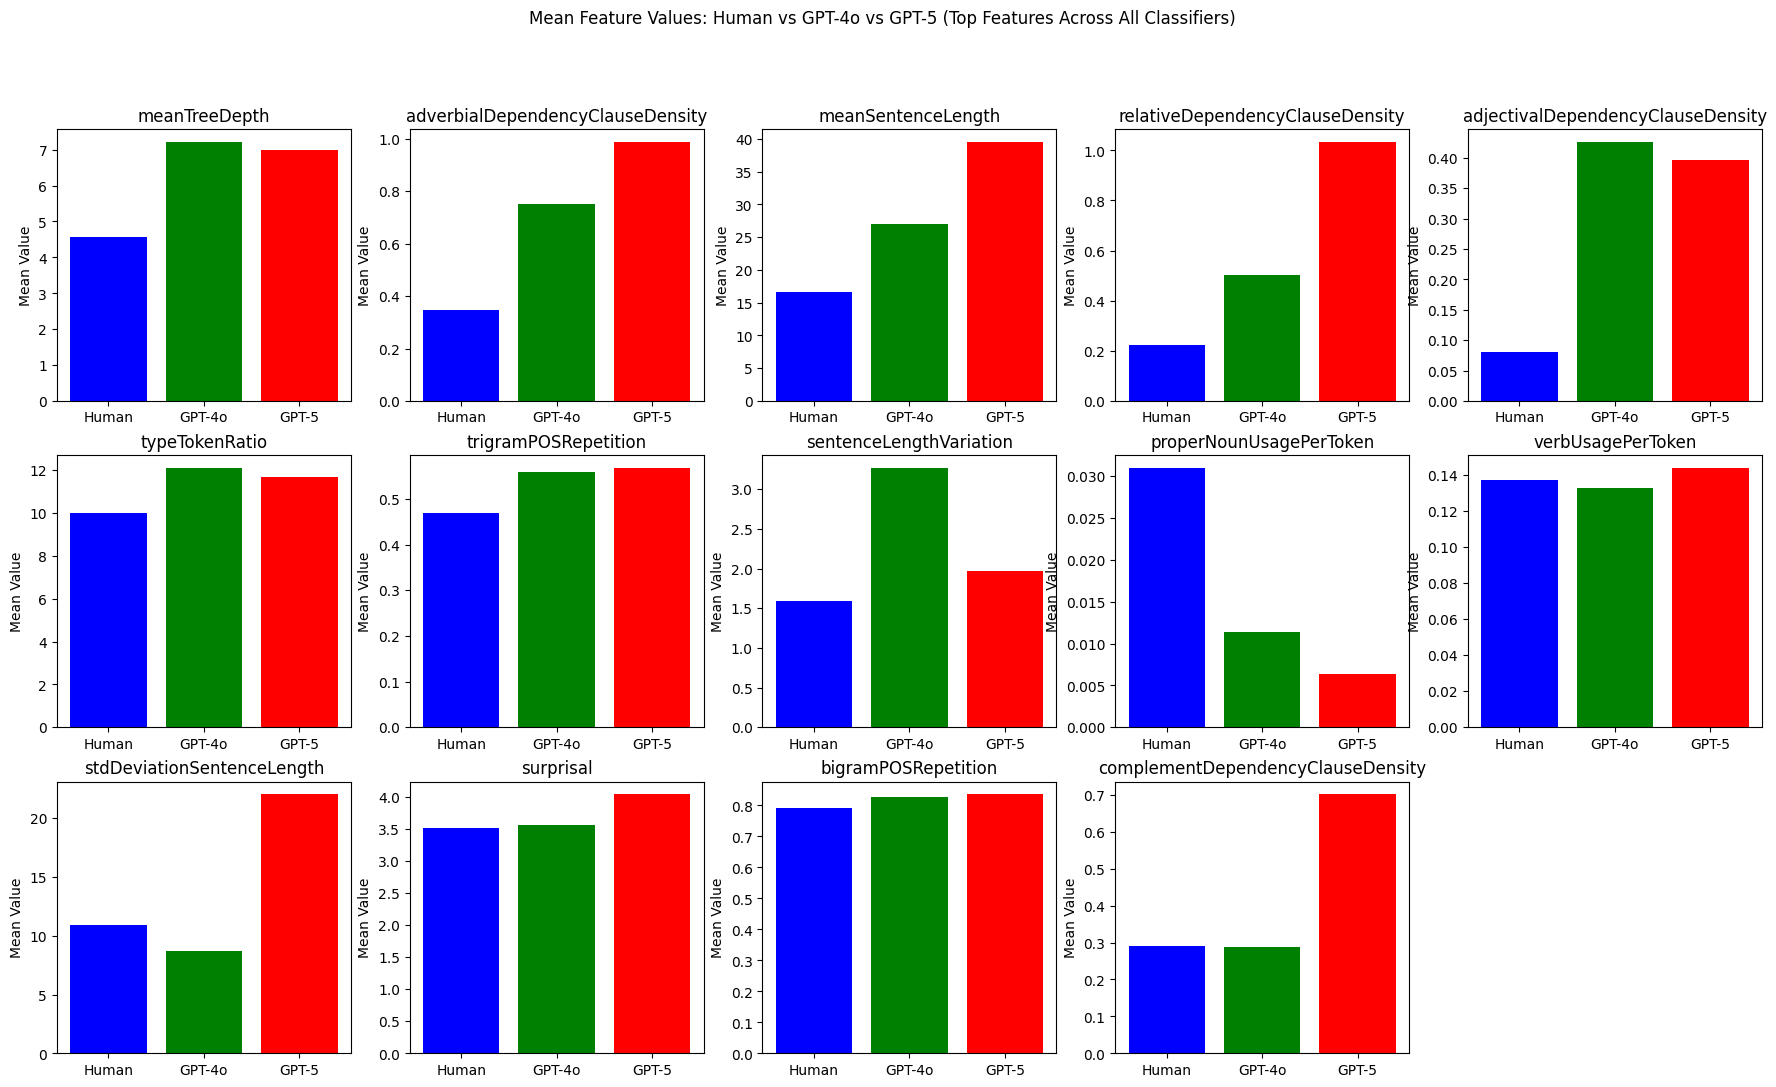

In [82]:
authorSpecificDf["group"] = authorSpecificDf["Author"].apply(
    lambda x: "Human" if x in humanAuthors else "AI"
)

seenFeatures = []
for features in [
    rfBinaryImportanceDf.head(7)["Feature"].tolist(),
    lrBinaryImportanceDf.head(7)["Feature"].tolist(),
    svmBinaryImportanceDf.head(7)["Feature"].tolist()
]:
    for feature in features:
        if feature not in seenFeatures:
            seenFeatures.append(feature)

groupLabels = ["Human", "GPT-4o", "GPT-5"]

def getGroupLabel(author):
    if author in humanAuthors:
        return "Human"
    elif "GPT-4o" in author:
        return "GPT-4o"
    else:
        return "GPT-5"

authorSpecificDf["modelGroup"] = authorSpecificDf["Author"].apply(getGroupLabel)

nCols = 5
nRows = math.ceil(len(seenFeatures) / nCols)
fig, axes = plt.subplots(nRows, nCols, figsize=(22, nRows * 4))
axes = axes.flatten()

for i, feature in enumerate(seenFeatures):
    groupMeans = authorSpecificDf.groupby("modelGroup")[feature].mean()
    values = [groupMeans.get(label, 0) for label in groupLabels]
    axes[i].bar(groupLabels, values, color=["blue", "green", "red"])
    axes[i].set_title(feature)
    axes[i].set_ylabel("Mean Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Mean Feature Values: Human vs GPT-4o vs GPT-5 (Top Features Across All Classifiers)")
plt.show()

# Results

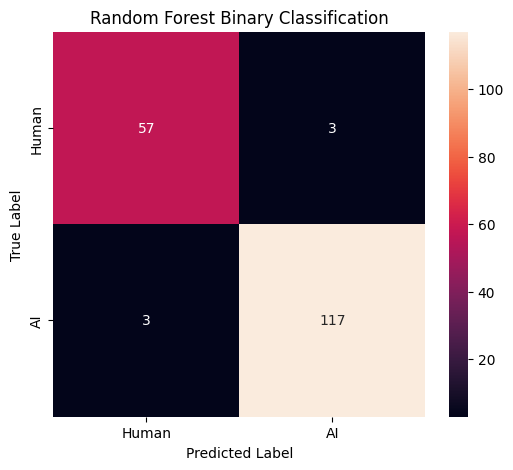

In [83]:
binaryLabels = ["Human", "AI"]

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(yAuthorTestBinary, rfAuthorBinaryPred),annot=True, fmt="d",xticklabels=binaryLabels, yticklabels=binaryLabels)
plt.title("Random Forest Binary Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

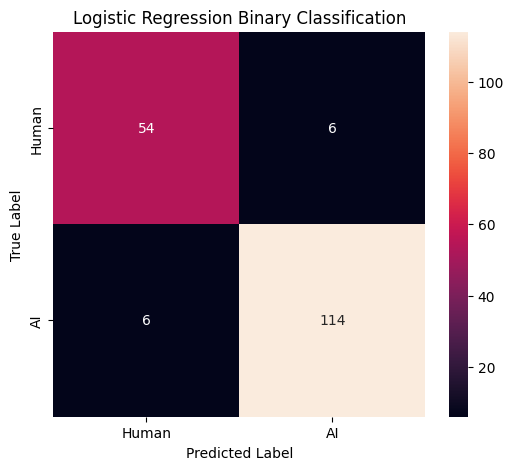

In [84]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(yAuthorTestBinary, lrAuthorBinaryPred),annot=True, fmt="d",xticklabels=binaryLabels, yticklabels=binaryLabels)
plt.title("Logistic Regression Binary Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

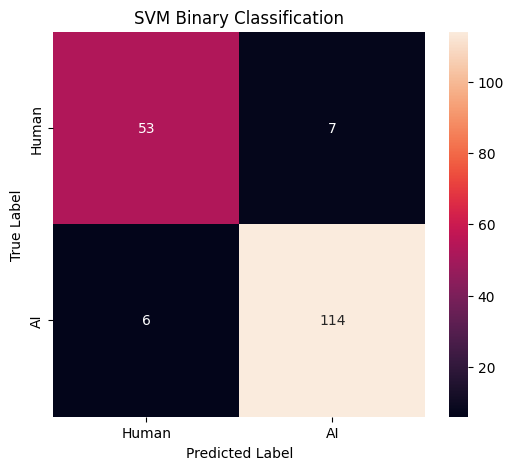

In [85]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(yAuthorTestBinary, svmAuthorBinaryPred),annot=True, fmt="d",xticklabels=binaryLabels, yticklabels=binaryLabels)
plt.title("SVM Binary Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

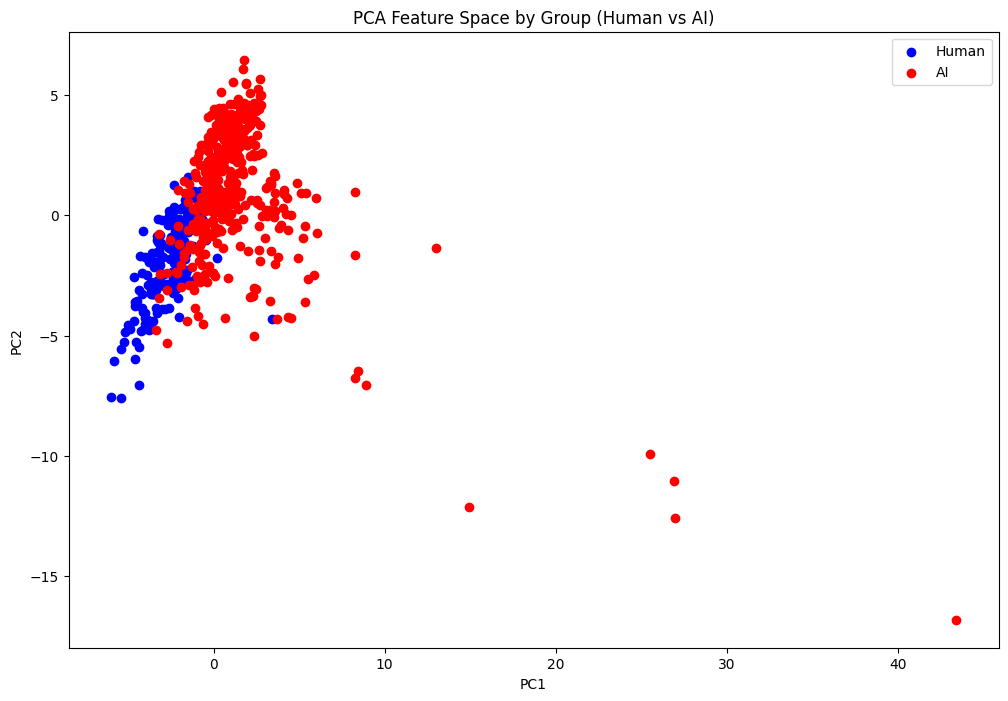

In [86]:
xAllScaled = binaryScaler.transform(xFeatures)
pca = PCA(n_components=2)
xPCA = pca.fit_transform(xAllScaled)

pcaDf = pd.DataFrame({
    "PC1": xPCA[:, 0],
    "PC2": xPCA[:, 1],
    "group": authorSpecificDf["group"],
    "Author": authorSpecificDf["Author"]
})

plt.figure(figsize=(12, 8))
colors = {"Human": "blue", "AI": "red"}

for group, colour in colors.items():
    mask = pcaDf["group"] == group
    plt.scatter(pcaDf[mask]["PC1"], pcaDf[mask]["PC2"],
                c=colour, label=group)

plt.title("PCA Feature Space by Group (Human vs AI)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

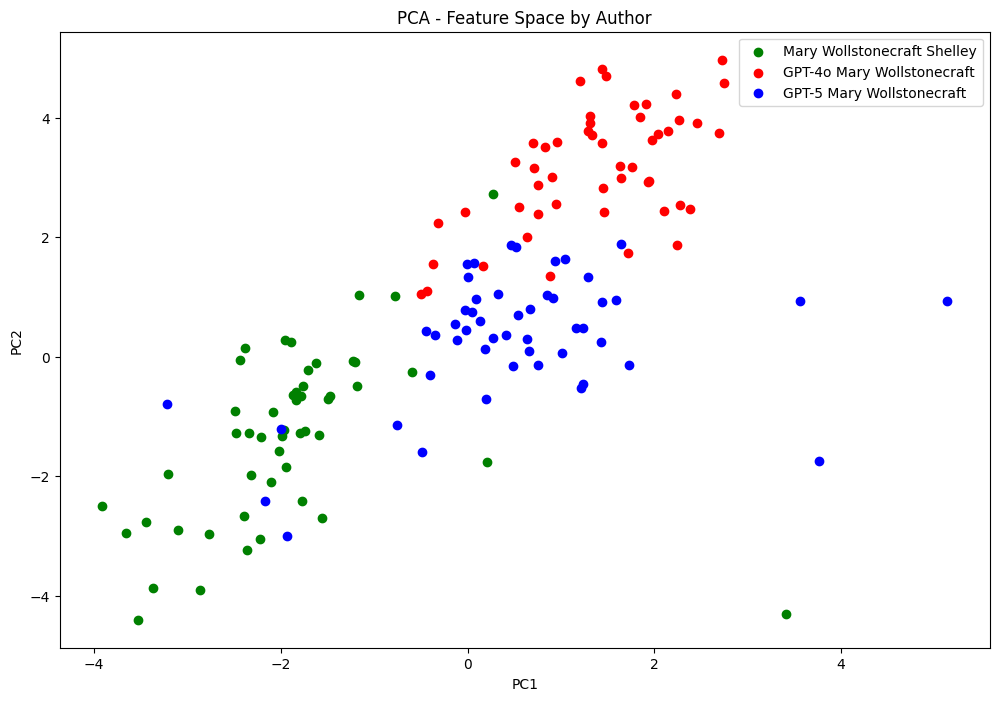

In [87]:
plt.figure(figsize=(12, 8))
colors = {
    "Mary Wollstonecraft Shelley": "green", "GPT-4o Mary Wollstonecraft": "red", "GPT-5 Mary Wollstonecraft": "blue",
}

for author, colour in colors.items():
    mask = pcaDf["Author"] == author
    plt.scatter(pcaDf[mask]["PC1"], pcaDf[mask]["PC2"],c=colour, label=author)

plt.title("PCA - Feature Space by Author")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

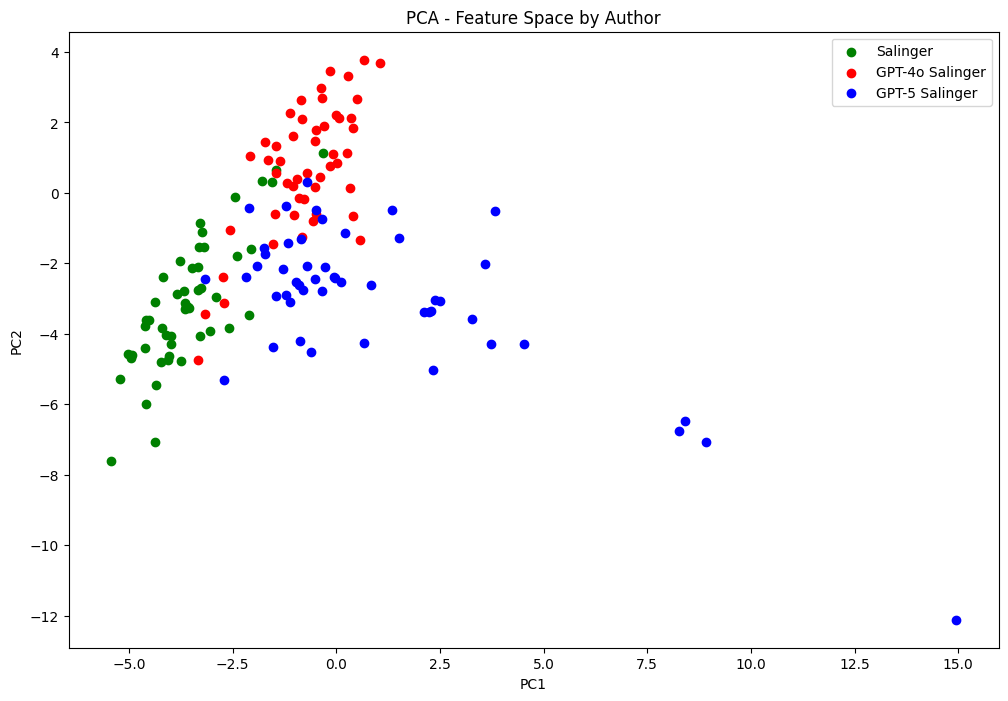

In [88]:
plt.figure(figsize=(12, 8))
colors = {
    "Salinger": "green", "GPT-4o Salinger": "red", "GPT-5 Salinger": "blue",
}

for author, colour in colors.items():
    mask = pcaDf["Author"] == author
    plt.scatter(pcaDf[mask]["PC1"], pcaDf[mask]["PC2"],
                c=colour, label=author)

plt.title("PCA - Feature Space by Author")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

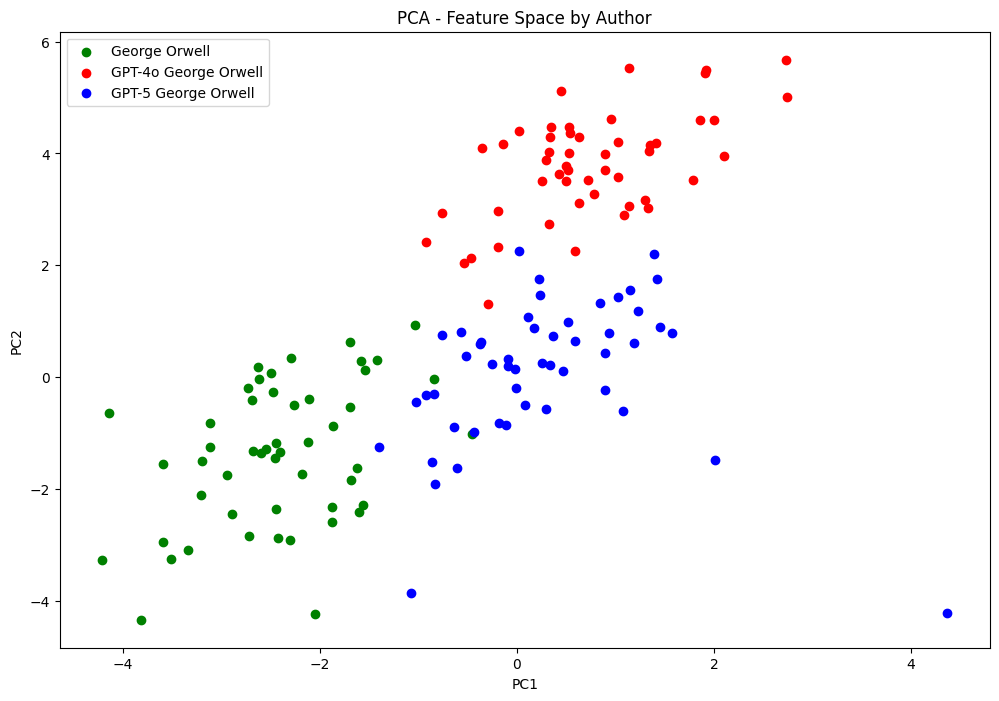

In [89]:
plt.figure(figsize=(12, 8))
colors = {
    "George Orwell": "green", "GPT-4o George Orwell": "red", "GPT-5 George Orwell": "blue",
}

for author, colour in colors.items():
    mask = pcaDf["Author"] == author
    plt.scatter(pcaDf[mask]["PC1"], pcaDf[mask]["PC2"],c=colour, label=author)


plt.title("PCA - Feature Space by Author")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

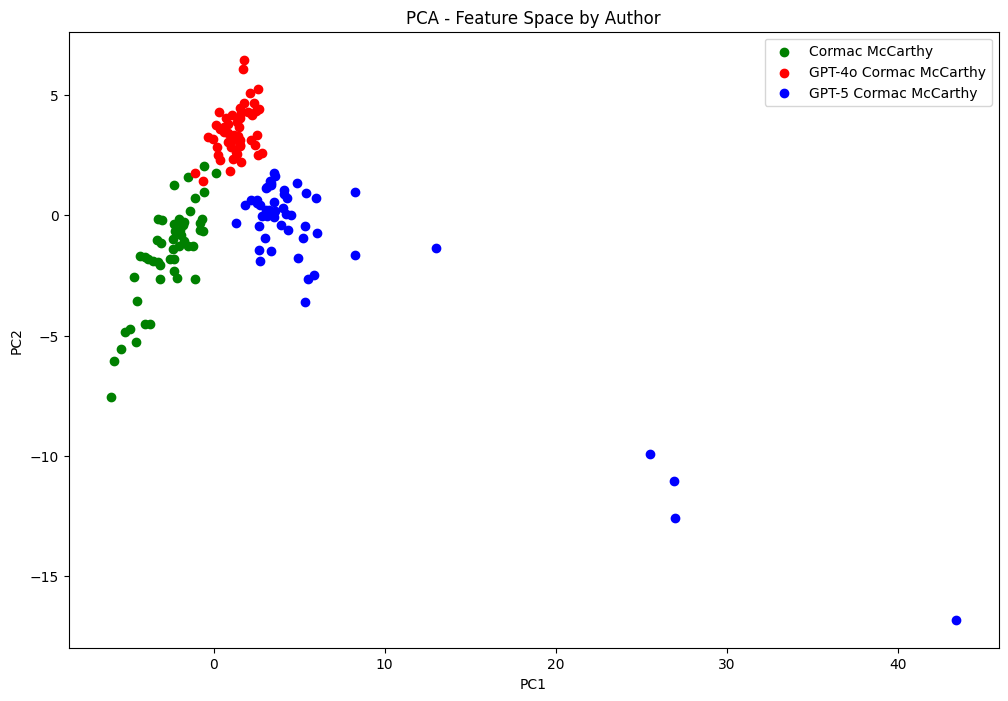

In [90]:
plt.figure(figsize=(12, 8))
colors = {
    "Cormac McCarthy": "green", "GPT-4o Cormac McCarthy": "red", "GPT-5 Cormac McCarthy": "blue",
}

for author, colour in colors.items():
    mask = pcaDf["Author"] == author
    plt.scatter(pcaDf[mask]["PC1"], pcaDf[mask]["PC2"],c=colour, label=author)

plt.title("PCA - Feature Space by Author")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

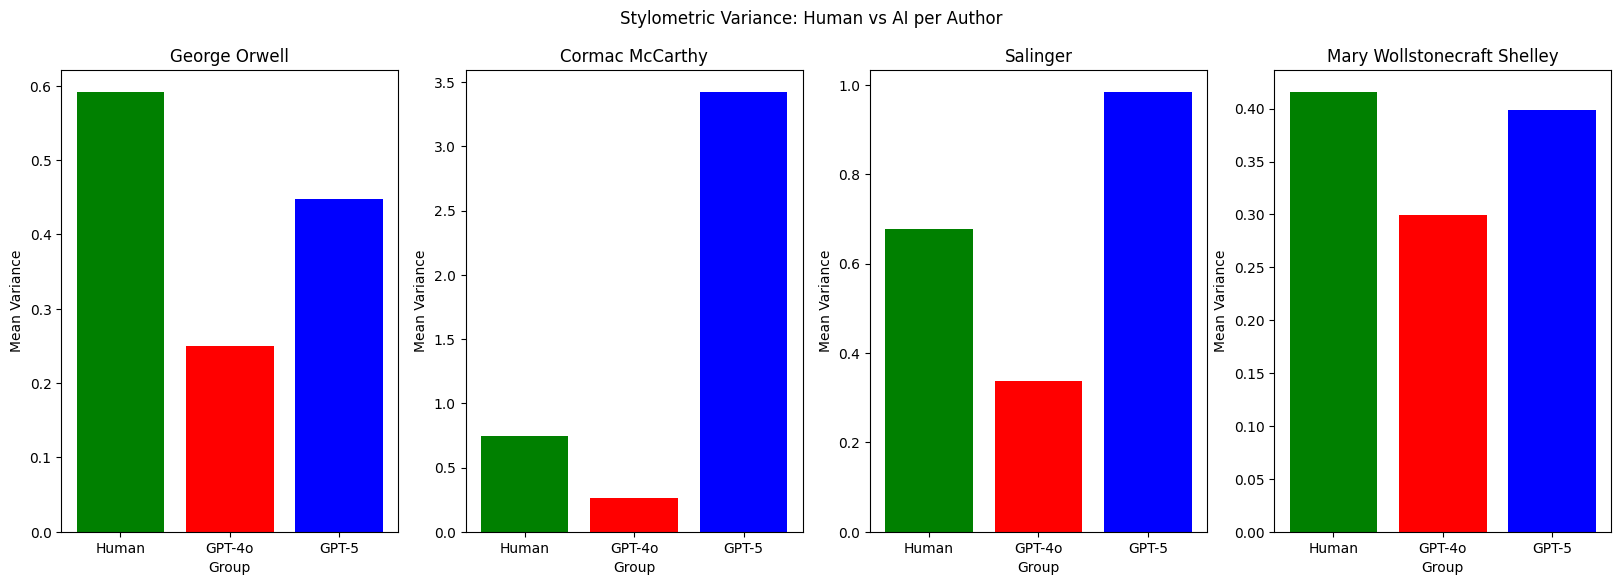

                     Author   Type  Mean Variance
              George Orwell  Human         0.5920
              George Orwell GPT-4o         0.2495
              George Orwell  GPT-5         0.4475
            Cormac McCarthy  Human         0.7456
            Cormac McCarthy GPT-4o         0.2620
            Cormac McCarthy  GPT-5         3.4263
                   Salinger  Human         0.6770
                   Salinger GPT-4o         0.3363
                   Salinger  GPT-5         0.9848
Mary Wollstonecraft Shelley  Human         0.4160
Mary Wollstonecraft Shelley GPT-4o         0.2995
Mary Wollstonecraft Shelley  GPT-5         0.3986


In [91]:
varianceResults = []

for human, gpt4o, gpt5 in comparisons:
    for group, label in [(human, "Human"), (gpt4o, "GPT-4o"), (gpt5, "GPT-5")]:
        mask = authorSpecificDf["Author"] == group
        features = xAllScaled[mask]
        variance = features.var(axis=0).mean()
        varianceResults.append({
            "Author": human,
            "Type": label,
            "Mean Variance": round(variance, 4)
        })

varianceDf = pd.DataFrame(varianceResults)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
authorNames = ["George Orwell", "Cormac McCarthy", "Salinger", "Mary Wollstonecraft Shelley"]

for i, authorName in enumerate(authorNames):
    authorData = varianceDf[varianceDf["Author"] == authorName]
    axes[i].bar(authorData["Type"], authorData["Mean Variance"],
                color=["green", "red", "blue"])
    axes[i].set_title(authorName)
    axes[i].set_xlabel("Group")
    axes[i].set_ylabel("Mean Variance")

plt.suptitle("Stylometric Variance: Human vs AI per Author")
plt.show()

print(varianceDf.to_string(index=False))

In [92]:
multiLabels = [
    "George Orwell",
    "Salinger",
    "Cormac McCarthy",
    "Mary Wollstonecraft Shelley",
    "GPT-4o George Orwell",
    "GPT-4o Salinger",
    "GPT-4o Cormac McCarthy",
    "GPT-4o Mary Wollstonecraft",
    "GPT-5 George Orwell",
    "GPT-5 Salinger",
    "GPT-5 Cormac McCarthy",
    "GPT-5 Mary Wollstonecraft",
]

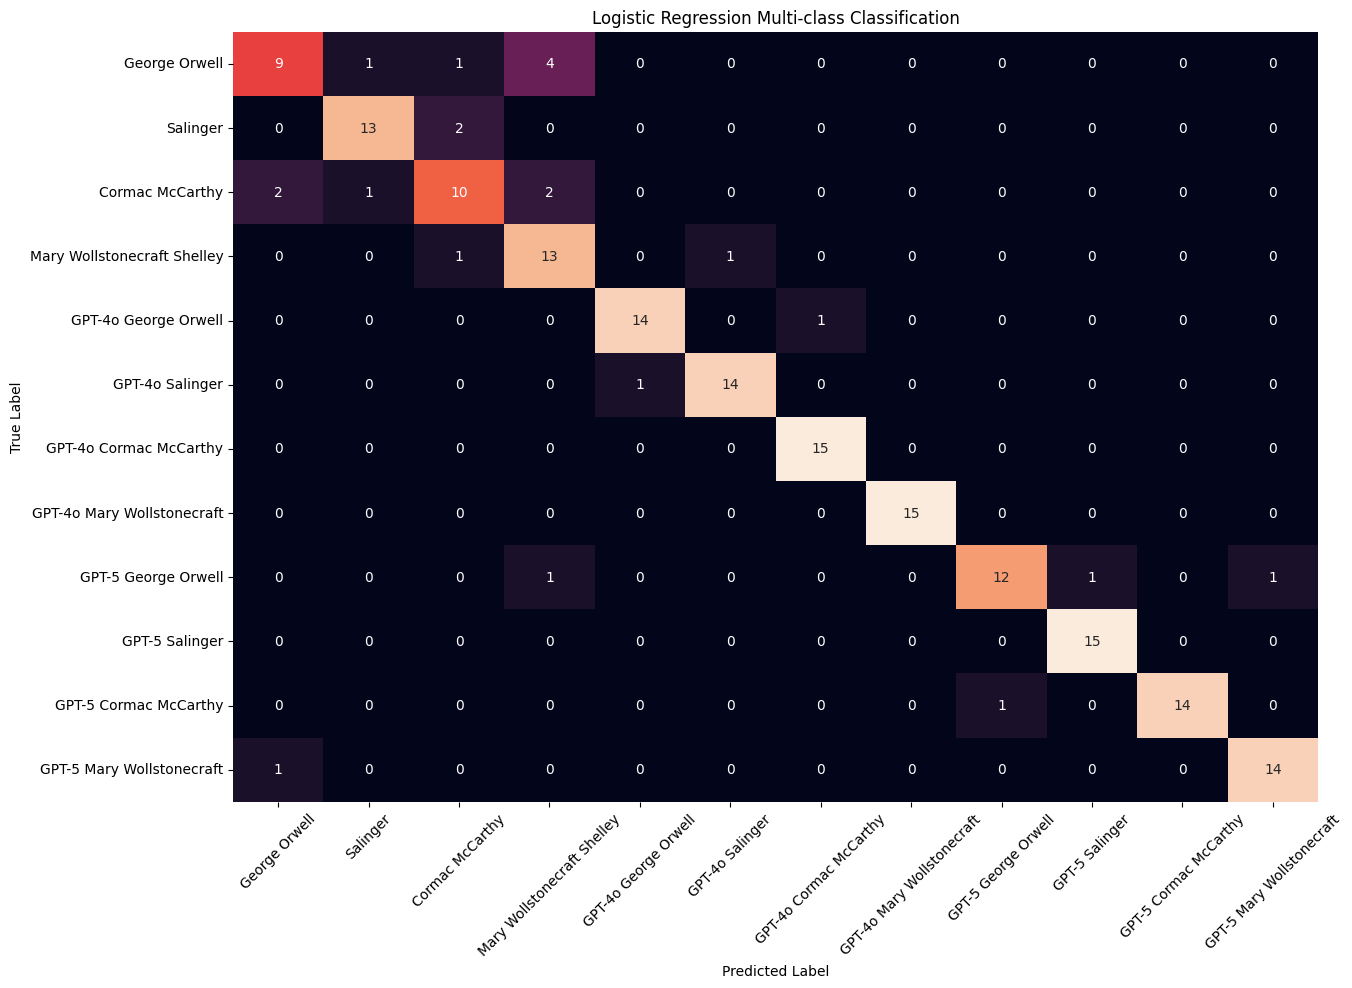

In [93]:
plt.figure(figsize=(14, 10))
sns.heatmap(confusion_matrix(yAuthorTestMulti, lrAuthorMultiPred),
            annot=True, fmt="d", cbar=False,
            xticklabels=multiLabels, yticklabels=multiLabels)
plt.title("Logistic Regression Multi-class Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45)
plt.show()

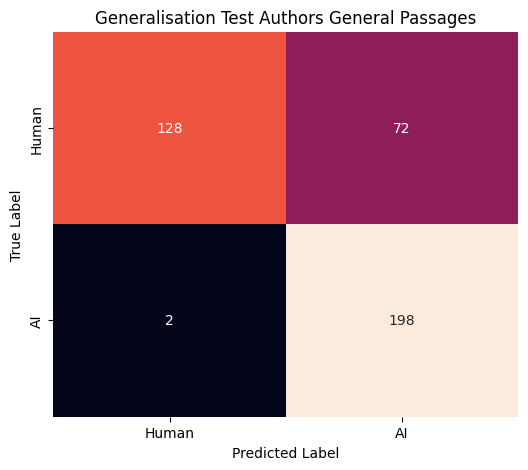

In [94]:
humanAuthors = ["George Orwell", "Cormac McCarthy", "Salinger", "Mary Wollstonecraft Shelley", "Human"]

generalPassagesDf['binaryLabel'] = generalPassagesDf['Author'].apply(lambda x: 0 if x in humanAuthors else 1)

copyFeatureCols = [col for col in featureCols if not col.startswith('LDA')]

scaler = StandardScaler()
xAuthorAllScaled = scaler.fit_transform(authorSpecificDf[copyFeatureCols].to_numpy())
yAuthorAll = authorSpecificDf["binaryLabel"]

rfGeneralise = RandomForestClassifier(random_state=1, class_weight="balanced")
rfGeneralise.fit(xAuthorAllScaled, yAuthorAll)

xGeneralScaled = scaler.transform(generalPassagesDf[copyFeatureCols].to_numpy())
yGeneral = generalPassagesDf["binaryLabel"]

generalPred = rfGeneralise.predict(xGeneralScaled)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(yGeneral, generalPred),
            annot=True, fmt="d",cbar=False,
            xticklabels=["Human", "AI"],
            yticklabels=["Human", "AI"])
plt.title("Generalisation Test Authors General Passages")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

           Dataset 1 (Author Specific)  Dataset 2 (General Passages)
Accuracy                        0.9667                        0.8150
Precision                       0.9667                        0.8590
Recall                          0.9667                        0.8150
F1                              0.9667                        0.8092


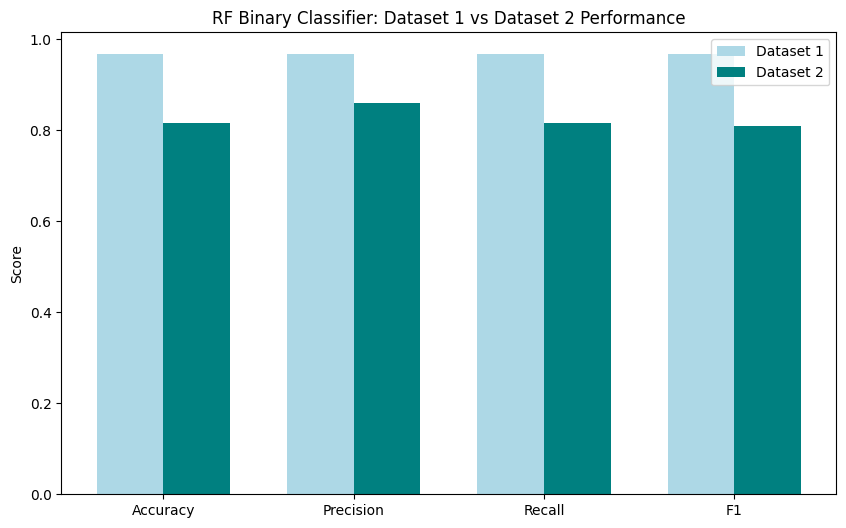

In [95]:
dataset1Metrics = {
    "Accuracy": accuracy_score(yAuthorTestBinary, rfAuthorBinaryPred),
    "Precision": precision_score(yAuthorTestBinary, rfAuthorBinaryPred, average="weighted"),
    "Recall": recall_score(yAuthorTestBinary, rfAuthorBinaryPred, average="weighted"),
    "F1": f1_score(yAuthorTestBinary, rfAuthorBinaryPred, average="weighted"),
}

dataset2Metrics = {
    "Accuracy": accuracy_score(yGeneral, generalPred),
    "Precision": precision_score(yGeneral, generalPred, average="weighted"),
    "Recall": recall_score(yGeneral, generalPred, average="weighted"),
    "F1": f1_score(yGeneral, generalPred, average="weighted"),
}

comparisonDf = pd.DataFrame({
    "Dataset 1 (Author Specific)": dataset1Metrics,
    "Dataset 2 (General Passages)": dataset2Metrics,
}).round(4)

print(comparisonDf.to_string())

metrics = ["Accuracy", "Precision", "Recall", "F1"]
xPosition = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(xPosition - width/2, [dataset1Metrics[m] for m in metrics], width,label="Dataset 1", color="lightblue")
ax.bar(xPosition + width/2, [dataset2Metrics[m] for m in metrics], width,label="Dataset 2", color="teal")

ax.set_xticks(xPosition)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("RF Binary Classifier: Dataset 1 vs Dataset 2 Performance")
ax.legend()
plt.show()

                         Feature  Importance      Std
                  typeTokenRatio    0.042600 0.008575
            trigramPOSRepetition    0.022527 0.002317
               nounUsagePerToken    0.018787 0.004202
         properNounUsagePerToken    0.017819 0.004960
             bigramPOSRepetition    0.014959 0.002597
calculateSentenceLengthVariation    0.014474 0.003866
      auxiliaryVerbUsagePerToken    0.009915 0.002243
         sentenceLengthVariation    0.007235 0.002865
                bigramRepetition    0.006752 0.002208
                functionWordRate    0.006631 0.002739
               verbUsagePerToken    0.006572 0.002737
      stdDeviationSentenceLength    0.004970 0.004110
                   meanTreeDepth    0.003983 0.006775
             adverbUsagePerToken    0.003212 0.001552
          adjectiveUsagePerToken    0.002494 0.002656


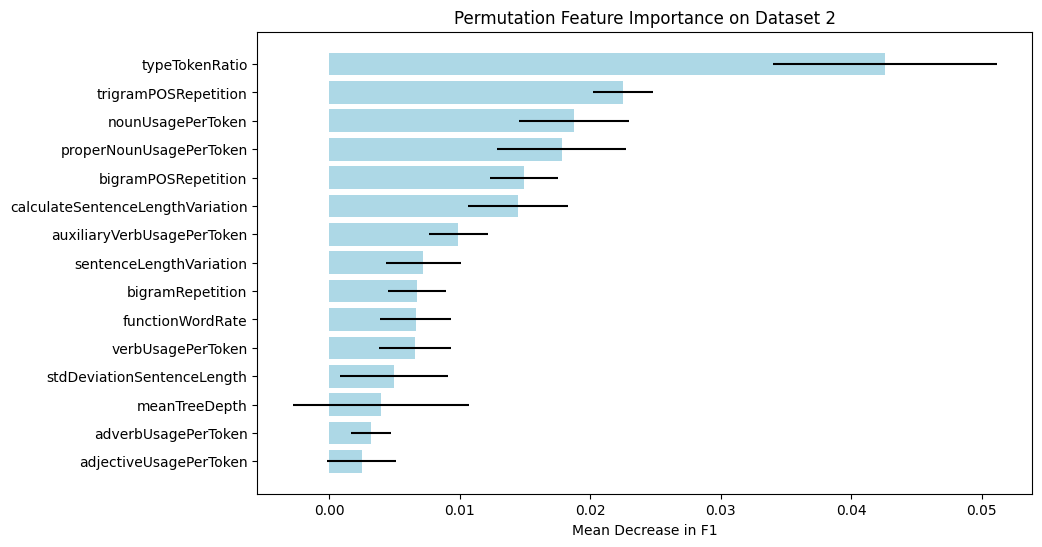

In [96]:
permImportance = permutation_importance(
    rfGeneralise,
    xGeneralScaled,
    yGeneral,
    n_repeats=10,
    random_state=1,
    scoring="f1"
)

permImportanceDf = pd.DataFrame({
    "Feature": copyFeatureCols,
    "Importance": permImportance.importances_mean,
    "Std": permImportance.importances_std
}).sort_values("Importance", ascending=False)

print(permImportanceDf.head(15).to_string(index=False))

top15 = permImportanceDf.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15["Feature"][::-1], top15["Importance"][::-1],
        xerr=top15["Std"][::-1],
        color="lightblue")
ax.set_xlabel("Mean Decrease in F1")
ax.set_title("Permutation Feature Importance on Dataset 2")
plt.show()

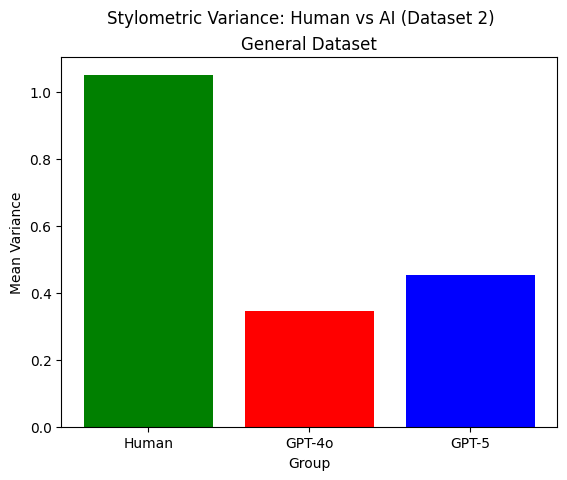

  Type  Mean Variance
 Human         1.0510
GPT-4o         0.3452
 GPT-5         0.4527


In [97]:
varianceResults2 = []

for group, label in [("Human", "Human"), ("GPT-4o", "GPT-4o"), ("GPT-5", "GPT-5")]:
    mask = generalPassagesDf["Author"] == group
    features = xGeneralScaled[mask.values]
    variance = pd.DataFrame(features).var(axis=0).mean()
    varianceResults2.append({
        "Type": label,
        "Mean Variance": round(variance, 4)
    })

varianceDf2 = pd.DataFrame(varianceResults2)

fig, ax = plt.subplots()
ax.bar(varianceDf2["Type"], varianceDf2["Mean Variance"],
       color=["green", "red", "blue"])
ax.set_title("General Dataset")
ax.set_xlabel("Group")
ax.set_ylabel("Mean Variance")

plt.suptitle("Stylometric Variance: Human vs AI (Dataset 2)")
plt.show()

print(varianceDf2.to_string(index=False))

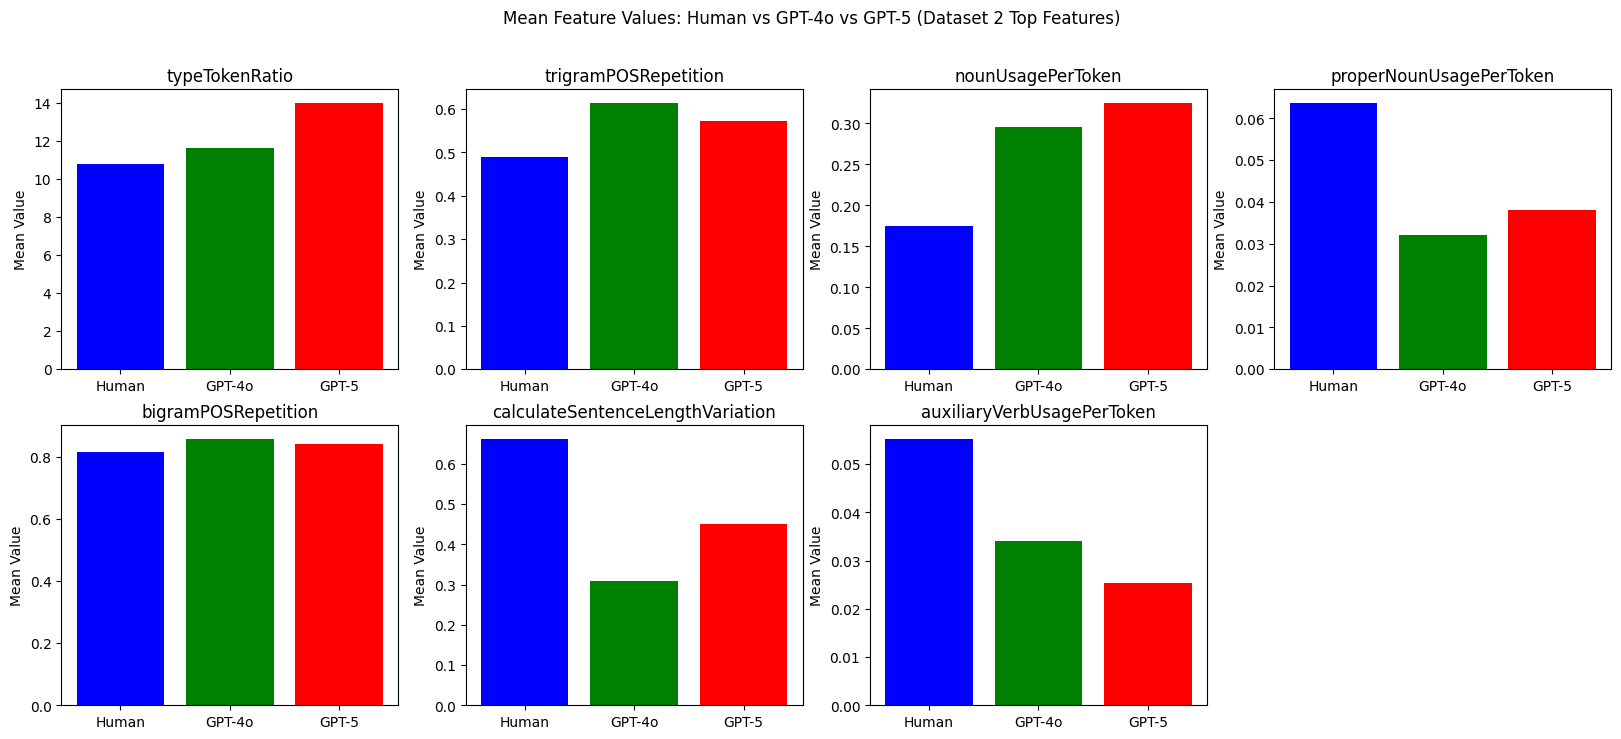

In [98]:
seenFeaturesGeneral = []
for feature in permImportanceDf.head(7)["Feature"].tolist():
    if feature not in seenFeaturesGeneral:
        seenFeaturesGeneral.append(feature)

groupLabels = ["Human", "GPT-4o", "GPT-5"]

nCols = 4
nRows = math.ceil(len(seenFeaturesGeneral) / nCols)
fig, axes = plt.subplots(nRows, nCols, figsize=(20, nRows * 4))
axes = axes.flatten()

for i, feature in enumerate(seenFeaturesGeneral):
    groupMeans = generalPassagesDf.groupby("Author")[feature].mean()
    values = [groupMeans.get(label, 0) for label in groupLabels]
    axes[i].bar(groupLabels, values, color=["blue", "green", "red"])
    axes[i].set_title(feature)
    axes[i].set_ylabel("Mean Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Mean Feature Values: Human vs GPT-4o vs GPT-5 (Dataset 2 Top Features)")
plt.show()